In [1]:
import pandas as pd
import shap
import joblib
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet(
    "../data/processed/energy_features_v3.parquet"
)

print(df.shape)

(9101, 31)


In [3]:
FEATURES = [
    "lag_1",
    "lag_7",
    "lag_30",

    "rolling_mean_7",
    "rolling_mean_30",

    "rolling_std_7",
    "rolling_std_30",

    "year",
    "month",
    "quarter",
    "day_of_week",
    "day_of_year",
    "is_weekend",

    "is_holiday",
    "is_christmas",
    "is_new_year",
    "is_easter",

    "temperature_mean",
    "temperature_max",
    "temperature_min",

    "rainfall",
    "wind_speed",

    "temp_lag_1",
    "rainfall_lag_1",
    "wind_lag_1",

    "EMBEDDED_SOLAR_GENERATION",
    "EMBEDDED_WIND_GENERATION",

    "solar_available",
    "wind_available"
]

In [4]:
split_date = "2024-01-01"

test = df[
    df["SETTLEMENT_DATE"] >= split_date
]

X_test = test[FEATURES]

In [5]:
model = joblib.load(
    "../models/xgboost_energy_forecaster_v3.pkl"
)

In [6]:
explainer = shap.TreeExplainer(
    model
)

shap_values = explainer.shap_values(
    X_test
)

print("SHAP ready")

SHAP ready


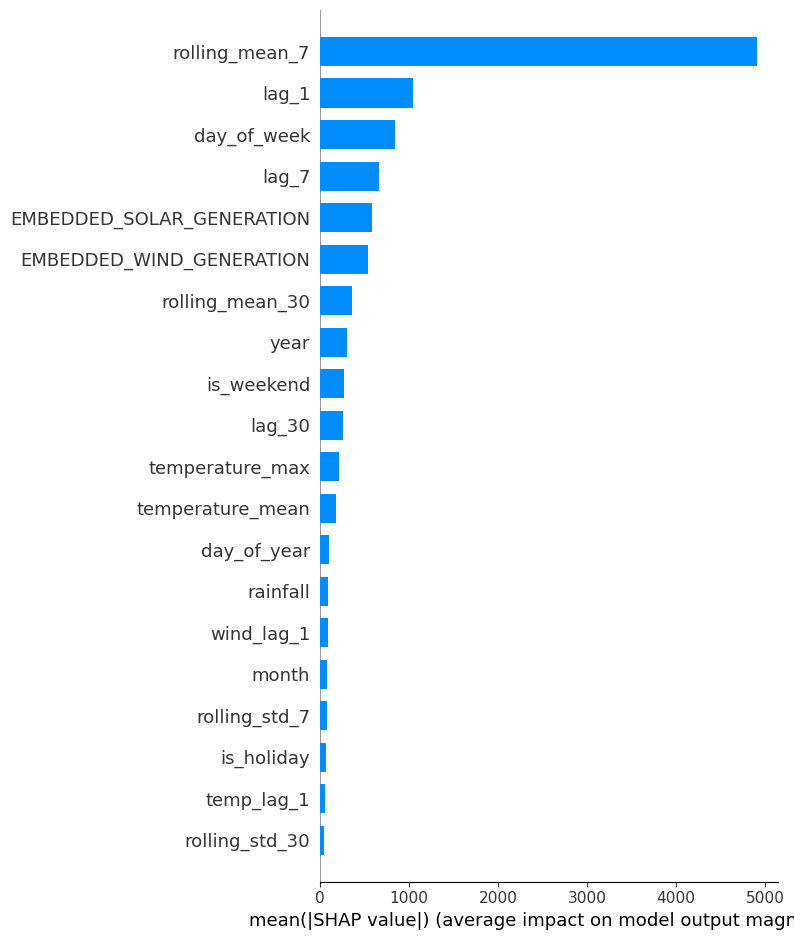

In [7]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

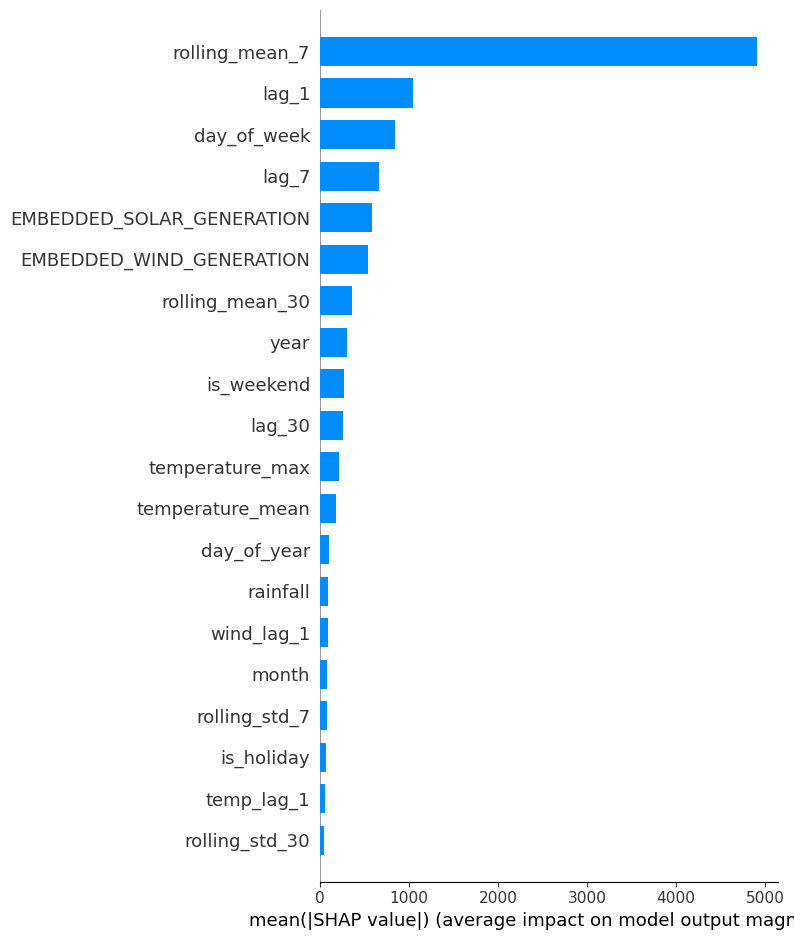

In [8]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.savefig(
    "../reports/figures/shap_v3_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()